In [2]:
#Import necessary libraries
import pdfplumber
import pandas as pd

In [3]:
# Extract data from pdf
def extract_pdf(file_path, party_name):
    data = []
    current_category = None

    category_map = {
        "Part A": "Advertising",
        "Part B": "Campaign Material",
        "Part C": "Operations",
        "Part D": "Staff",
        "Part E": "Office",
        "Part F": "Travel",
        "Part G": "Research",
        "Part H": "Fundraising"
    }

    with pdfplumber.open(file_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            tables = page.extract_tables()

            # Detect category
            if text:
                for key in category_map:
                    if key in text:
                        current_category = category_map[key]

            # Skip pages without tables or category
            if not tables or current_category is None:
                continue

            # Process tables
            for table in tables:
                if not table:
                    continue

                header = None
                header_found = False

                date_idx = None
                supplier_idx = None
                desc_idx = None
                amount_idx = None

                #Detect header
                for row in table:
                    row_clean = [(c or "").strip().lower() for c in row]

                    if not header_found:
                        # Check if this row is header
                        if any("amount" in c for c in row_clean):
                            header = row_clean
                            header_found = True

                            # Detect indices
                            for i, col in enumerate(header):
                                if "date" in col and "candidate" not in col:
                                    date_idx = i
                                if "supplier" in col or "provider" in col:
                                    supplier_idx = i
                                if "description" in col:
                                    desc_idx = i
                                if "amount" in col and ("inc" in col or "incl" in col): # Include gst 
                                    amount_idx = i

                            # Fallback to include any amount column
                            if amount_idx is None:
                                for i, col in enumerate(header):
                                    if "amount" in col:
                                        amount_idx = i

                        continue  # move to next row after header 

                    # Process actual data rows (after header)
                    try:
                        if amount_idx is None:
                            continue

                        if not row or amount_idx >= len(row):
                            continue

                        amount = row[amount_idx]

                        if amount is None or str(amount).strip() == "":
                            continue

                        date = row[date_idx] if date_idx is not None and date_idx < len(row) else None
                        supplier = row[supplier_idx] if supplier_idx is not None and supplier_idx < len(row) else "Unknown"
                        description = row[desc_idx] if desc_idx is not None and desc_idx < len(row) else None

                        data.append({
                            "Party": party_name,
                            "Date": date,
                            "Supplier": supplier,
                            "Description": description,
                            "Amount": amount,
                            "Category": current_category
                        })

                    except:
                        continue

    # Return dataframe
    return pd.DataFrame(data, columns=[
        "Party", "Date", "Supplier", "Description", "Amount", "Category"
    ])


# Cleaning DataFrame
def clean_data(df):
    df = df.copy()

    if df.empty:
        return df

    # Clean Amount
    df["Amount"] = (df["Amount"].astype(str).str.replace(r"[^\d\.-]", "", regex=True)) # remove everything except numbers,dots,minus
    df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

    # Clean Date
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce") # as date in format DD/MM/YYYY

    # Drop invalid rows
    df = df.dropna(subset=["Amount", "Date"])

    return df


# Load data
labor = extract_pdf("C:/Users/akhii/OneDrive/Desktop/NSW expenditure analytics/Re_ Capstone Project (DATA7901) – NSW Electoral Expenditure Analytics/Labor Party.pdf", "Labor")

liberal = extract_pdf("C:/Users/akhii/OneDrive/Desktop/NSW expenditure analytics/Re_ Capstone Project (DATA7901) – NSW Electoral Expenditure Analytics/Liberal Party.pdf", "Liberal")

national = extract_pdf("C:/Users/akhii/OneDrive/Desktop/NSW expenditure analytics/Re_ Capstone Project (DATA7901) – NSW Electoral Expenditure Analytics/National Party.pdf", "National")

# Combine
df = pd.concat([labor, liberal, national], ignore_index=True)
print("Total extracted rows:", len(df))
print("Rows with valid amount:", df["Amount"].notna().sum())
print("Rows with valid date:", df["Date"].notna().sum())

# Clean
df = clean_data(df)

print("\nTotal spending by party:\n", df.groupby("Party")["Amount"].sum())

print("\nSample rows:")
print(df.head(10))
df.to_csv("C:/Users/akhii/OneDrive/Desktop/NSW expenditure analytics/Re_ Capstone Project (DATA7901) – NSW Electoral Expenditure Analytics/Cleaned_Expenditure.csv",index=False)

KeyboardInterrupt: 

Party
Liberal     3009561.85
Labor       2239181.36
National    1010193.94
Name: Amount, dtype: float64


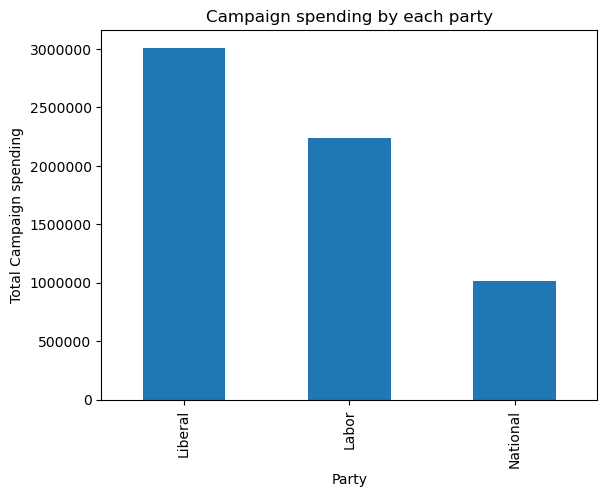

In [3]:
cleaned_df=pd.read_csv("C:/Users/akhii/OneDrive/Desktop/NSW expenditure analytics/Re_ Capstone Project (DATA7901) – NSW Electoral Expenditure Analytics/Cleaned_Expenditure.csv")

party_spending = cleaned_df.groupby("Party")["Amount"].sum().sort_values(ascending=False)
print(party_spending) # Campaign spending by each party

#Bar chart for spending
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
ax = party_spending.plot(kind='bar')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')
plt.ylabel("Total Campaign spending")
plt.title("Campaign spending by each party")
plt.savefig("C:/Users/akhii/OneDrive/Desktop/DATA 7901/Barchartforspending.png")
plt.show()

Category  Advertising  Campaign Material  Fundraising     Office  Operations  \
Party                                                                          
Labor      1263968.60           48254.76      1652.53   38869.12    98137.38   
Liberal      96166.18           53067.50     91837.78  141299.58    21397.66   
National    107719.42           16739.00     67047.62   96744.61     5481.46   

Category    Research      Staff    Travel  
Party                                      
Labor      635100.42  143944.93   9253.62  
Liberal   2100305.90  489576.24  15911.01  
National   422756.78  289186.05   4519.00  


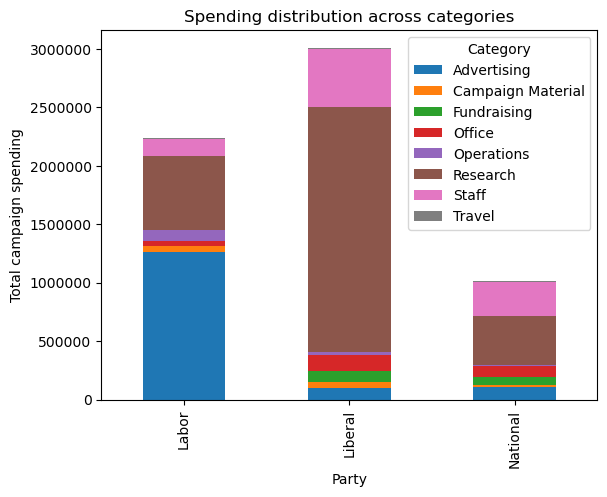

In [24]:
# Spending by category
category_spend=cleaned_df.groupby(["Party","Category"])["Amount"].sum().unstack()
print(category_spend)

# Stacked bar chart for categories
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
ax=category_spend.plot(kind='bar',stacked=True)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')
plt.ylabel("Total campaign spending")
plt.title("Spending distribution across categories")
plt.savefig("C:/Users/akhii/OneDrive/Desktop/DATA 7901/StackedBarChartforCategories.png")
plt.show()

Category  Advertising  Campaign Material  Fundraising  Office  Operations  \
Party                                                                       
Labor           56.45               2.16         0.07    1.74        4.38   
Liberal          3.20               1.76         3.05    4.70        0.71   
National        10.66               1.66         6.64    9.58        0.54   

Category  Research  Staff  Travel  
Party                              
Labor        28.36   6.43    0.41  
Liberal      69.79  16.27    0.53  
National     41.85  28.63    0.45  


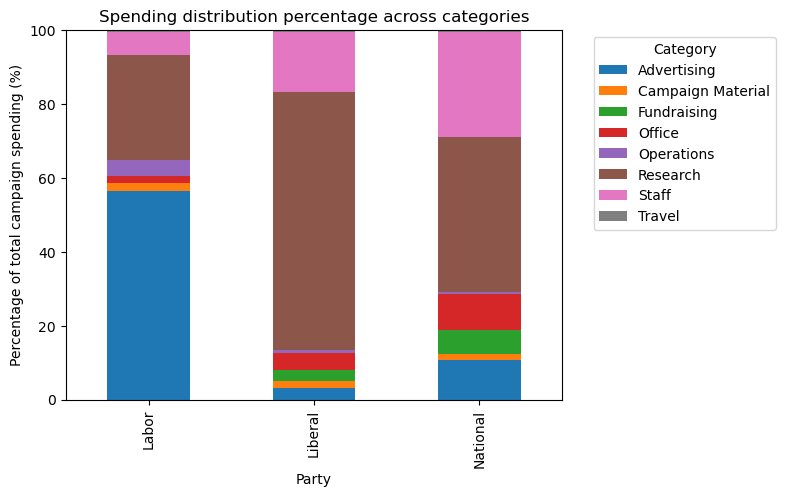

In [25]:
# Percentage of category spends by each party
category_pct= (category_spend.div(category_spend.sum(axis=1),axis=0)*100).round(2)
print(category_pct)

# Stacked bar chart for categories %
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
ax = category_pct.plot(kind='bar', stacked=True)
ax.set_ylim(0, 100) # Fix y-axis for percentage
plt.ylabel("Percentage of total campaign spending (%)")
plt.title("Spending distribution percentage across categories")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.savefig("C:/Users/akhii/OneDrive/Desktop/DATA 7901/StackedBarChartforCategories(%).png")
plt.show()


In [14]:
# Statistics of Party Expenditures
cleaned_df.groupby("Party")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Party,,,,,,,,
Labor,328.0,6826.772439,30939.200933,-3.10,30.000,328.765,2548.5475,440000.00
Liberal,303.0,9932.547360,36961.243347,5.29,199.875,785.000,3140.5000,368008.30
National,379.0,2665.419367,13910.303704,1.14,65.095,250.000,2667.5000,257362.32


        Party        Date                     Supplier  \
25      Labor  13-01-2023  The Shannon Company Pty Ltd   
574   Liberal  28-02-2023  C | T GROUP (CROSBY/TEXTOR)   
577   Liberal  30-03-2023  C | T GROUP (CROSBY/TEXTOR)   
799  National  01-10-2022                      Unknown   
477   Liberal  25-03-2023                      Unknown   
27      Labor  13-01-2023  The Shannon Company Pty Ltd   
556   Liberal  31-01-2023  C | T GROUP (CROSBY/TEXTOR)   
22      Labor  13-12-2022  The Shannon Company Pty Ltd   
554   Liberal  31-01-2023  C | T GROUP (CROSBY/TEXTOR)   
476   Liberal  24-02-2023                      Unknown   

                                           Description     Amount     Category  
25   Services Agreement Between NSW Labor and TSC a...  440000.00  Advertising  
574   CT GROUP-CAMPAIGN MARGINAL SEAT TRACK 50% OF TOT  368008.30     Research  
577   CT GROUP-CAMPAIGN MARGINAL SEAT TRACK 50% OF TOT  368008.30     Research  
799                              Camp

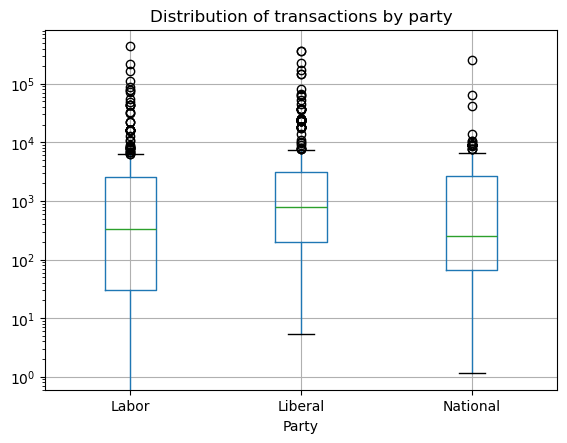

In [4]:
# High value expenditures or transactions
print(cleaned_df.sort_values("Amount",ascending=False).head(10))

#Box plot to detect outliers 
import matplotlib.pyplot as plt
ax=cleaned_df.boxplot(column=['Amount'],by='Party')
ax.get_figure().suptitle("")
plt.yscale('log')
plt.title("Distribution of transactions by party")
plt.savefig("C:/Users/akhii/OneDrive/Desktop/DATA 7901/BOXplot.png")
plt.show()

Party        Labor     Liberal   National
Month                                    
2022-06    9091.54         NaN        NaN
2022-07   60471.34     1000.00   71191.10
2022-08   13931.56     1758.95   56512.60
2022-09    6759.92    28299.03    4275.00
2022-10   40325.67    91907.92  261843.78
2022-11   57498.14   108327.30  225070.11
2022-12  677680.88   259624.05   12615.99
2023-01  869455.97   552089.30   55625.38
2023-02  332423.24  1100058.65  215734.03
2023-03  171374.62   866496.65  107325.95
2023-04     168.48         NaN        NaN


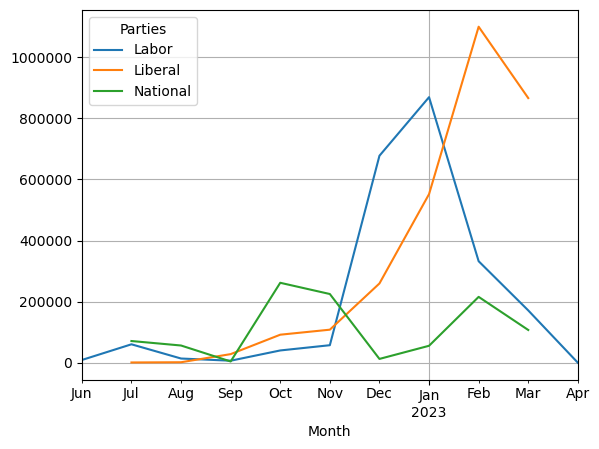

In [8]:
# Time based Expenditure Analysis
cleaned_df["Date"]=pd.to_datetime(cleaned_df["Date"],dayfirst=True)
cleaned_df["Month"]=cleaned_df["Date"].dt.to_period('M')
monthly=cleaned_df.groupby(["Month","Party"])["Amount"].sum().unstack()
print(monthly)

# Line chart to track spending over time
import matplotlib.pyplot as plt
ax=monthly.plot(kind='line',grid=True)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')
plt.legend(title='Parties',loc='upper left') # move legend outisde
plt.savefig("C:/Users/akhii/OneDrive/Desktop/DATA 7901/LineChartForspendingOvertime.png")
plt.show()

In [25]:
# Top Suppliers by earnings
top_suppliers= cleaned_df.groupby(["Party","Supplier"])["Amount"].sum().reset_index()
top_suppliers.sort_values(["Party","Amount"],ascending=[True,False]).groupby("Party").head(10)

,Party,Supplier,Amount
52,Labor,The Shannon Company Pty Ltd,1254000.00
3,Labor,BANNERTYNE HOUSE,299860.00
54,Labor,UTTING RESEARCH,273900.00
55,Labor,Unknown,143944.93
0,Labor,AUSTRALIA POST,91858.75
57,Labor,YOUGOV GALAXY,49500.00
23,Labor,JEFFRIES PRINTING SERVICES,30578.62
30,Labor,Mercer Property Pty Ltd,11988.43
6,Labor,COMMUNITY ENGAGEMENT LIMITED,9000.00
13,Labor,DEFT REAL ESTATE,6861.36
